# Analysis Code 

At first, I load all the libraries we will need later on.

In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from scipy import interpolate

We have 
\begin{equation}
\text{BR} (h\to\nu_\mu\nu_\mu\phi) = \frac{1}{\Gamma_h}\frac{ \lambda^2 m_h^3}{ 3\cdot 2^8 \pi^3 v^2 }  \times  \Big[(1\!-\!x_{\phi h})[x_{\phi h}(x_{\phi h}\!+\!10)\!+\!1] 
 +6x_{\phi h}(1\!+\!x_{\phi h})\log(x_{\phi h}) \Big] 
\end{equation}


In [4]:
def br(m,c):
    mh, v, pi, x, gamma = 125, 246, 3.1415, m/125., 0.004
    prefac = mh**3 / (3 * 2**8 * pi**3 * v**2)
    massfac = (1-x)*(x*(x+10)+1) + 6*x*(1+x)*np.log(x)
    return c**2 * prefac * massfac / gamma

In [31]:
masses = np.logspace(-3,np.log10(124))
lambdas = [np.sqrt(0.001/br(m,1)/2) for m in masses ]
joint = np.array([[m,l] for m,l in zip(masses, lambdas)])

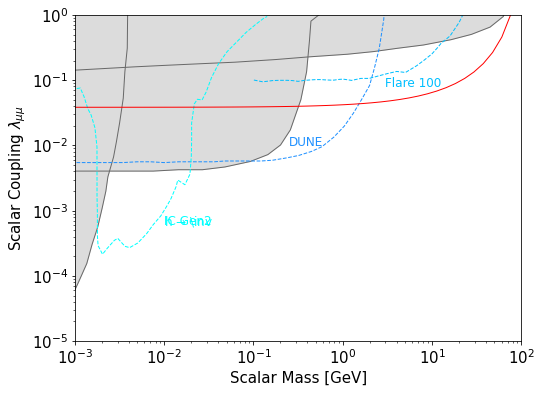

In [32]:
# initiate figure
matplotlib.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(8,6))

# Add Constraints
data=np.loadtxt("lines/0v2b.txt")
ax.fill(data.T[0], data.T[1], color="gainsboro")
ax.plot(data.T[0], data.T[1], color="dimgray", lw=1)

data=np.loadtxt("lines/mlnuphi.txt")
ax.fill(data.T[0], data.T[1], color="gainsboro")
ax.plot(data.T[0], data.T[1], color="dimgray", lw=1)

data=np.loadtxt("lines/Zinv.txt")
ax.fill(data.T[0], data.T[1], color="gainsboro")
ax.plot(data.T[0], data.T[1], color="dimgray", lw=1)


# Add Projections
#data=np.loadtxt("lines/Projection_MC3v.txt")
#ax.plot(data.T[0], data.T[1], color="blue", lw=1, ls='dashed')
#plt.text(0.1, 2e-3,"vDIS @ MC3 10kg", color="blue", fontsize=12)

#data=np.loadtxt("lines/Projection_MC3v_ton.txt")
#ax.plot(data.T[0], data.T[1], color="blue", lw=1, ls='dashed')
#plt.text(0.1, 8e-5,"vDIS @ MC3 1ton", color="blue", fontsize=12)

data=np.loadtxt("lines/DUNE.txt")
ax.plot(data.T[0], data.T[1], color="dodgerblue", lw=1, ls='dashed')
plt.text(0.25, 1e-2,"DUNE", color="dodgerblue", fontsize=12)

data=np.loadtxt("lines/100tonne_FLARE.txt")
ax.plot(data.T[0], data.T[1], color="deepskyblue", lw=1, ls='dashed')
plt.text(3, 8e-2,"Flare 100", color="deepskyblue", fontsize=12)

data=np.loadtxt("lines/IceCube_Gen-2.txt")
ax.plot(data.T[0], data.T[1], color="cyan", lw=1, ls='dashed')
plt.text(0.01, 6e-4,"IC Gen2", color="cyan", fontsize=12)

# Get lines
ax.plot(masses, lambdas, color="red", lw=1, ls='solid')
plt.text(0.01, 6e-4,r"h $\to$ \inv", color="cyan", fontsize=12)

# Target Lines
#data=np.loadtxt("Lines/Target_CScalar.txt")
#ax.plot(data.T[0], data.T[1], color="k",lw=2, ls="dashed")
#data=np.loadtxt("Lines/Target_Dirac.txt")
#ax.plot(data.T[0], data.T[1], color="k",lw=2, ls="dotted")
#data=np.loadtxt("Lines/Target_Sterile.txt")
#ax.plot(data.T[0], data.T[1], color="k",lw=2, ls="dashdot")

# Axes 
ax.set_xlabel(r"Scalar Mass [GeV]")
ax.set_ylabel(r"Scalar Coupling $\lambda_{\mu\mu}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.001,100)
ax.set_ylim(0.00001,1)
    
#finalize plot
plt.show()

In [37]:
masses = np.logspace(-3,np.log10(124))
lambdas = [np.sqrt(0.001/br(m,1)/2.) for m in masses ]
joint = np.array([[m,l] for m,l in zip(masses, lambdas)])
np.savetxt('lines/hinv_mc10.txt',joint)
print(joint[0])

masses = np.logspace(-3,np.log10(124))
lambdas = [np.sqrt(0.005/br(m,1)/2.) for m in masses ]
joint = np.array([[m,l] for m,l in zip(masses, lambdas)])
np.savetxt('lines/hinv_mc10.txt',joint)
print(joint[0])

[0.001      0.03842183]
[0.001      0.08591382]
